# Flux Comparison of HRDPS 1km, HRDPS 2.5km, HRDPS 10km and CaSR Outputs

## Load Data

In [1]:
# Paths 

path_CaSR_flux='/ocean/jqiu/results/Flux/flux_01mar23_CaSR/SalishSea_1d_20230301_20230301_sbfx_T.nc'
path_HRDPS1_flux='/ocean/jqiu/results/Flux/flux_01mar23_hrdps1/SalishSea_1d_20230301_20230301_sbfx_T.nc'
path_HRDPS25_flux='/ocean/jqiu/results/Flux/flux_01mar23_hrdps2.5/SalishSea_1d_20230301_20230301_sbfx_T.nc'
path_HRDPS10_flux='/ocean/jqiu/results/Flux/flux_01mar23_hrdps10/SalishSea_1d_20230301_20230301_sbfx_T.nc'



In [ ]:
# load data and inspect variables

import xarray as xr

ds_CaSR_flux=xr.open_dataset(path_CaSR_flux)
ds_HRDPS1_flux=xr.open_dataset(path_HRDPS1_flux)
ds_HRDPS25_flux=xr.open_dataset(path_HRDPS25_flux)
ds_HRDPS10_flux=xr.open_dataset(path_HRDPS10_flux)
# print(ds_CaSR_flux)

<xarray.Dataset> Size: 23MB
Dimensions:               (y: 898, x: 398, nvertex: 4, time_counter: 1,
                           axis_nbounds: 2)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
    time_centered         (time_counter) datetime64[ns] 8B ...
  * time_counter          (time_counter) datetime64[ns] 8B 2023-03-01T12:00:00
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 16B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 16B ...
    longwave_heat_flux    (time_counter, y, x) float32 1MB ...
    sensible_heat_flux    (time_counter, y, x) float32 1MB ...
    latent_heat_flux      (time_counter, y, x) float32 1MB ...
    emp_heat_flux


### Interesting variables

    longwave_heat_flux    (time_counter, y, x) float32 1MB ...
    sensible_heat_flux    (time_counter, y, x) float32 1MB ...
    latent_heat_flux      (time_counter, y, x) float32 1MB ...
    emp_heat_flux         (time_counter, y, x) float32 1MB ...
    wind_stress           (time_counter, y, x) float32 1MB ...

All the heat fluxes above are downward. Wind stress stands for magnitude of surface downward stress.

Total heat budget may require short wave radiation, which we don't have here. It's included in the forcing data.

In [7]:
for v in [
    "longwave_heat_flux",
    "sensible_heat_flux",
    "latent_heat_flux",
    "emp_heat_flux",
    "shortwave_heat_flux",
    "wind_stress",
]:
    if v in ds_CaSR_flux:
        print(v, ds_CaSR_flux[v].attrs)

longwave_heat_flux {'standard_name': 'surface_net_downward_longwave_flux', 'long_name': 'Longwave Downward Heat Flux over open ocean', 'units': 'W/m2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}
sensible_heat_flux {'standard_name': 'surface_downward_sensible_heat_flux', 'long_name': 'Sensible Downward Heat Flux over open ocean', 'units': 'W/m2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}
latent_heat_flux {'standard_name': 'surface_downward_latent_heat_flux', 'long_name': 'Latent Downward Heat Flux over open ocean', 'units': 'W/m2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}
emp_heat_flux {'long_name': 'Downward Heat Flux from E-P

## Wind Stress Scatter 

### All 24 Hour Data

In [8]:
# Extract Wind Stress

ws_CaSR=ds_CaSR_flux['wind_stress'].values.ravel()
ws_HRDPS1=ds_HRDPS1_flux['wind_stress'].values.ravel()
ws_HRDPS25=ds_HRDPS25_flux['wind_stress'].values.ravel()
ws_HRDPS10=ds_HRDPS10_flux['wind_stress'].values.ravel()

# Calculate RMSE

import numpy as np

rmse_CaSR=np.sqrt(
        np.nanmean((ws_CaSR - ws_HRDPS25) ** 2)
    )

rmse_HRDPS1=np.sqrt(
        np.nanmean((ws_HRDPS1 - ws_HRDPS25) ** 2)
    )

rmse_HRDPS10=np.sqrt(
        np.nanmean((ws_HRDPS10 - ws_HRDPS25) ** 2)
    )

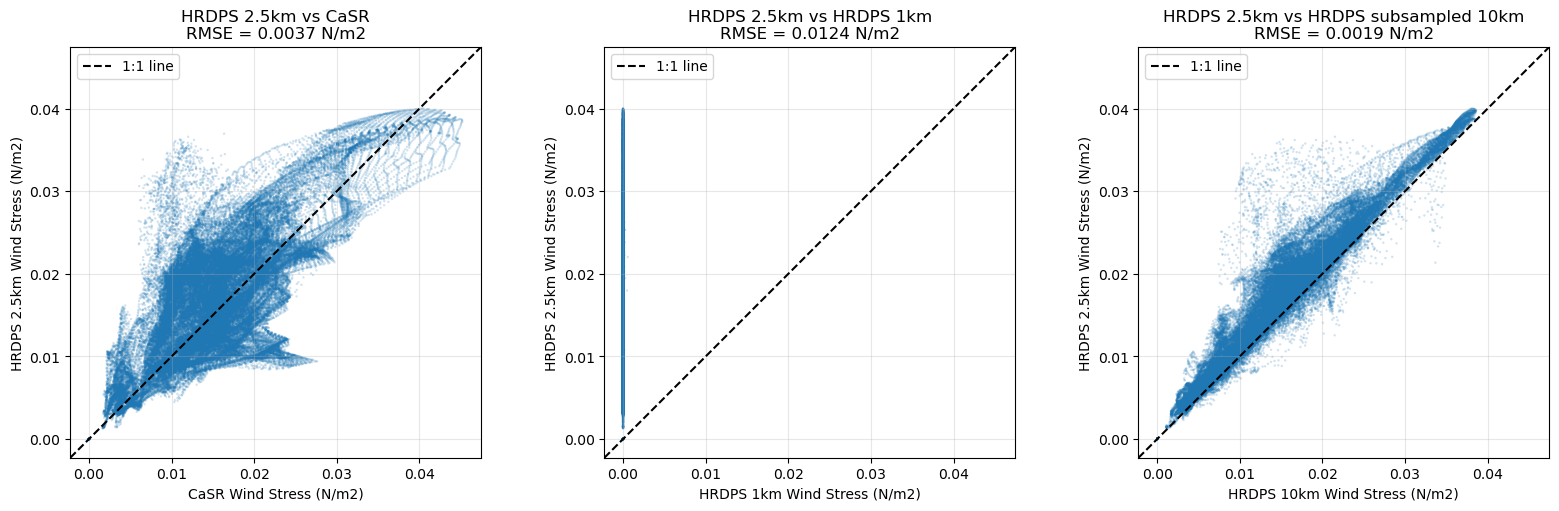

In [14]:
# Visualize
import matplotlib.pyplot as plt


fig, axes = plt.subplots(
    1,3,
    figsize=(16, 5),
    constrained_layout=True
)

# value range 

lower = min(
    np.nanmin(ws_CaSR),
    np.nanmin(ws_HRDPS1),
    np.nanmin(ws_HRDPS25),
    np.nanmin(ws_HRDPS10),
)

upper = max(
    np.nanmax(ws_CaSR),
    np.nanmax(ws_HRDPS1),
    np.nanmax(ws_HRDPS25),
    np.nanmax(ws_HRDPS10),
)

# add some extra space
padding = 0.05 * (upper - lower)

if padding == 0:
    padding = 0.5

lower -= padding
upper += padding

# visualize
# -----------------------------
# CaSR
axes[0].scatter(
    ws_CaSR,
    ws_HRDPS25,
    s=3,
    alpha=0.2,
    edgecolors="none"
)

# reference line
axes[0].plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    color="k",
    label="1:1 line"
)

axes[0].set_xlim(lower, upper)
axes[0].set_ylim(lower, upper)
axes[0].set_aspect("equal", adjustable="box")

axes[0].set_xlabel("CaSR Wind Stress (N/m2)")
axes[0].set_ylabel("HRDPS 2.5km Wind Stress (N/m2)")

axes[0].set_title(
        "HRDPS 2.5km vs CaSR\n"
        f"RMSE = {rmse_CaSR:.4f} N/m2"
    )

axes[0].grid(alpha=0.3)
axes[0].legend()

# --------------------------

# visualize
# -----------------------------
# HRDPS 1km
axes[1].scatter(
    ws_HRDPS1,
    ws_HRDPS25,
    s=3,
    alpha=0.2,
    edgecolors="none"
)

# reference line
axes[1].plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    color="k",
    label="1:1 line"
)

axes[1].set_xlim(lower, upper)
axes[1].set_ylim(lower, upper)
axes[1].set_aspect("equal", adjustable="box")

axes[1].set_xlabel("HRDPS 1km Wind Stress (N/m2)")
axes[1].set_ylabel("HRDPS 2.5km Wind Stress (N/m2)")

axes[1].set_title(
        "HRDPS 2.5km vs HRDPS 1km\n"
        f"RMSE = {rmse_HRDPS1:.4f} N/m2"
    )

axes[1].grid(alpha=0.3)
axes[1].legend()

# --------------------------

# visualize
# -----------------------------
# HRDPS 10km
axes[2].scatter(
    ws_HRDPS10,
    ws_HRDPS25,
    s=3,
    alpha=0.2,
    edgecolors="none"
)

# reference line
axes[2].plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    color="k",
    label="1:1 line"
)

axes[2].set_xlim(lower, upper)
axes[2].set_ylim(lower, upper)
axes[2].set_aspect("equal", adjustable="box")

axes[2].set_xlabel("HRDPS 10km Wind Stress (N/m2)")
axes[2].set_ylabel("HRDPS 2.5km Wind Stress (N/m2)")

axes[2].set_title(
        "HRDPS 2.5km vs HRDPS subsampled 10km\n"
        f"RMSE = {rmse_HRDPS10:.4f} N/m2"
    )

axes[2].grid(alpha=0.3)
axes[2].legend()

# --------------------------

plt.show()

In [11]:
print(np.nanmax(ws_HRDPS1))
print(np.nanmin(ws_HRDPS1))


0.00056898495
0.0


**Something is wrong with the HRDPS1 data. Need another look.**